# Homework for Lab 3.2

## 3.2.1 TensorDatasets for MNIST



In [ ]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import v2

pre_transforms = v2.Compose([
v2.ToImage(),
v2.ToDtype(torch.float32, scale=True),
v2.Normalize((0.5,), (0.5,))
])

mnist_train = datasets.MNIST(root='data', train=True, download=True, transform=pre_transforms)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=pre_transforms)
mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [50000,10000]) # obtain train set and validation set

#### Dataloaders

In [18]:
import torch.utils.data as data
import matplotlib.pyplot as plt

train_data_loader = data.DataLoader(mnist_train, batch_size=512, shuffle=True)
valid_data_loader = data.DataLoader(mnist_val, batch_size=512)
test_data_loader = data.DataLoader(mnist_test, batch_size=512)

batch_train = next(iter(train_data_loader))
train_image, train_label = batch_train

print(f"shape: {train_image.shape}\n data type: {type(train_image)}\n value range: [{train_image.min()}, {train_image.max()}]")

shape: torch.Size([512, 1, 28, 28])
 data type: <class 'torch.Tensor'>
 value range: [-1.0, 1.0]


In [19]:
from torch.utils.data import TensorDataset

# converts a dataset (subset or actual dataset) to a TensorDataset with transformations applied
def split_to_tensor_dataset(dataset):

    if isinstance(dataset, torch.utils.data.Subset):
        data = dataset.dataset.data[dataset.indices]
        labels = dataset.dataset.targets[dataset.indices]
    elif isinstance(dataset, torch.utils.data.Dataset):
        data = dataset.data
        labels = dataset.targets
    

    # apply pre-transform
    transformed_data = []
    for img in data:
        transformed_img = pre_transforms(img)
        transformed_data.append(transformed_img)
    
    # recreate tensor
    data = torch.stack(transformed_data)
    
    return TensorDataset(data, labels)

# Conversions

tdataset_train = split_to_tensor_dataset(mnist_train)
tdataset_valid = split_to_tensor_dataset(mnist_val)
tdataset_test = split_to_tensor_dataset(mnist_test)
print(tdataset_train.tensors[0])

print(f"shape: {tdataset_train.tensors[0].shape}\n data type: {type(tdataset_train.tensors[0][0])}\n value range: [{tdataset_train.tensors[0][0].min()}, {tdataset_train.tensors[0][0].max()}]")



tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]],


        [[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]],


        [[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]],


        ...,


        [[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., 

#### CAE
 
We want to :  
1 - Implement a suitable CAE with a bottleneck size (smallest latent dimension) of
64 (or (64, 1, 1)).   
2 - Train the CAE using the lazy DataLoaders for 10 epochs and
your TensorDatasets for 10 epochs with the Adam optimizer and a learning rate of
10^3.  
3 - Compare the epoch time of the lazy DataLoader pipeline to the TensorDataset
pipeline.  

In [20]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [21]:
import torch.nn as nn

loss_module = nn.MSELoss()

In [22]:

td_train_data_loader = data.DataLoader(tdataset_train, batch_size=512, shuffle=True)
td_valid_data_loader = data.DataLoader(tdataset_valid, batch_size=512)
td_test_data_loader = data.DataLoader(tdataset_test, batch_size=512)

##### Model

In [23]:
class AutoEncoder(nn.Module):

    
    def __init__(self):
        # Initialize the modules we need to build the network
        super().__init__()
        

        # encoder func
        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1) # in_channel (grey or RGB), nb of filter, filter size, stride
        self.maxpool = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1) # , nb of filter, filter size, stride
        self.adaptive_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear1 = nn.Linear(64, 64)
        self.linear2 = nn.Linear(64, 10) # 64 after conv2 and 10 is the ouput range

        
        # decoder func
        self.linear3 = nn.Linear(10, 64)
        self.linearreshape = nn.Linear(64,64*7*7) # we choose de same dimension as the final encoder one
        self.convt1 = nn.ConvTranspose2d(64, 32, 3, 2, 1, 1)
        self.convt2 = nn.ConvTranspose2d(32, 16, 3, 2, 1, 1)
        self.convt3 = nn.ConvTranspose2d(16, 1, 3, 1, 1) # 16 x28x28 -> we found our initial image dimensions





    def forward(self, x):


        # convolution 1
        x = self.conv1(x)
        x = self.relu(x)    # 14x14x32
        x = self.maxpool(x) # 7x7x32

        # convulotion 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # fully connected layers
        x = self.adaptive_avg_pool(x)
        x = torch.flatten(x, start_dim=1, end_dim=-1)        
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)

        # decoder
        x = self.linear3(x)
        x = self.relu(x)
        x = self.linearreshape(x) # list of 64 nb -> creating list of 64*7*7 creating
        x = x.view(-1, 64, 7, 7)

        x = self.convt1(x)
        x = self.relu(x)
        x = self.convt2(x)
        x = self.relu(x)
        x = self.convt3(x)

        # use tanh as output fonction
        x = torch.tanh(x) 


        return x

##### Training

In [30]:
import numpy as np
from tqdm.notebook import tqdm

auto_encoder_lazy = AutoEncoder()
auto_encoder_td = AutoEncoder()
auto_encoder_lazy.to(device)
auto_encoder_td.to(device)

optimizer_lazy = torch.optim.Adam(auto_encoder_lazy.parameters(), lr=0.001)
optimizer_td = torch.optim.Adam(auto_encoder_td.parameters(), lr=0.001)

def train_model_autoencoder(model, optimizer, data_loader, loss_module, num_epochs=20):
    model.train()
    losses = []
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = []
        for data_inputs, _ in data_loader: 

            data_inputs = data_inputs.to(device)
            preds = model(data_inputs)

            loss = loss_module(preds, data_inputs)
            epoch_loss.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        losses.append(np.mean(epoch_loss))

    return losses

train_loss_lazy = train_model_autoencoder(auto_encoder_lazy, optimizer_lazy, train_data_loader, loss_module, 10)
train_loss_tensorDataset = train_model_autoencoder(auto_encoder_td, optimizer_td, td_train_data_loader, loss_module, 10)



  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

#### Results analysis

**lazy dataloader approach**: 6.05s/epoch
**TensorDataset dataloader approach**: 1.48s/epoch

The first approach is slower beacause every time a batch is loaded, the transformation must be applied, whereas the second approach transforms the data once and reuse it after.

## 3.2.2 Adding Augmentations

In [25]:
# task 2 imports

import torch
from torchvision import datasets, transforms
from torchvision.transforms import v2
import torch.utils.data as data
import matplotlib.pyplot as plt


### Augmentation for lazy pipeline

In [26]:

# image verification
# plt.imshow(train_image[23][0], cmap = 'gray')

transforms = v2.Compose([
    # augmentation
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=-1), # we want to match the background if possible (black)

    # pre transforms
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

mnist_train_aug = datasets.MNIST(root='data', train=True, download=True, transform=transforms)
mnist_test_aug = datasets.MNIST(root='data', train=False, download=True, transform=transforms)
mnist_train_aug, mnist_val_aug = torch.utils.data.random_split(mnist_train_aug, [50000,10000]) # obtain train set and validation set

In [27]:
import torch.utils.data as data


train_data_loader_aug = data.DataLoader(mnist_train, batch_size=512, shuffle=True)
valid_data_loader_aug = data.DataLoader(mnist_val, batch_size=512)
test_data_loader_aug = data.DataLoader(mnist_test, batch_size=512)

In [28]:
import numpy as np
from tqdm.notebook import tqdm

auto_encoder_lazy_aug = AutoEncoder()
auto_encoder_lazy_aug.to(device)

optimizer_lazy_aug = torch.optim.Adam(auto_encoder_lazy_aug.parameters(), lr=0.001)


train_loss_lazy_aug = train_model_autoencoder(auto_encoder_lazy_aug, optimizer_lazy_aug, train_data_loader_aug, loss_module, 10)

  0%|          | 0/10 [00:00<?, ?it/s]

#### Affichage

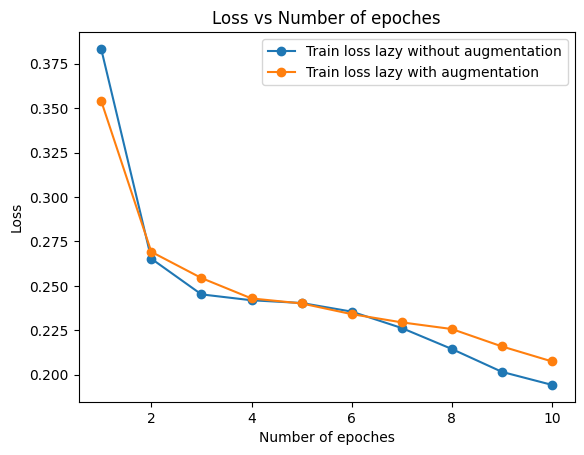

In [31]:
import matplotlib.pyplot as plt

epoches = np.arange(1,11)
plt.plot(epoches, train_loss_lazy, marker='o', label='Train loss lazy without augmentation')
plt.plot(epoches, train_loss_lazy_aug, marker='o', label='Train loss lazy with augmentation')

plt.xlabel("Number of epoches")
plt.ylabel("Loss")
plt.title("Loss vs Number of epoches")
plt.legend()

plt.show()

### Augmentation for TensorDataset pipeline

In [32]:
class AugmentedTensorDataset(TensorDataset):
    def __init__(self, tensor_dataset, transforms=None):
        self.tensor_dataset = tensor_dataset
        self.transforms = transforms

    def __len__(self):
        return len(self.tensor_dataset)

    def __getitem__(self, idx):
        data, label = self.tensor_dataset[idx]
        if self.transforms:
            data = self.transforms(data)

        return data, label

augmentations =  v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=-1)
])

# datasets
tdataset_train_aug = AugmentedTensorDataset(tdataset_train, transforms=augmentations)
tdataset_valid_aug = AugmentedTensorDataset(tdataset_valid, transforms=augmentations)
tdataset_test_aug = AugmentedTensorDataset(tdataset_test, transforms=augmentations)

# dataloaders
td_train_data_loader_aug = data.DataLoader(tdataset_train_aug, batch_size=512, shuffle=True)
td_valid_data_loader_aug = data.DataLoader(tdataset_valid_aug, batch_size=512)
td_test_data_loader_aug = data.DataLoader(tdataset_test_aug, batch_size=512)

In [33]:
auto_encoder_td_aug = AutoEncoder()
auto_encoder_td_aug.to(device)
optimizer_td_aug = torch.optim.Adam(auto_encoder_td_aug.parameters(), lr=0.001)

train_loss_tensorDataset_aug = train_model_autoencoder(auto_encoder_td_aug, optimizer_td_aug, td_train_data_loader_aug, loss_module, 10)

  0%|          | 0/10 [00:00<?, ?it/s]

#### Results

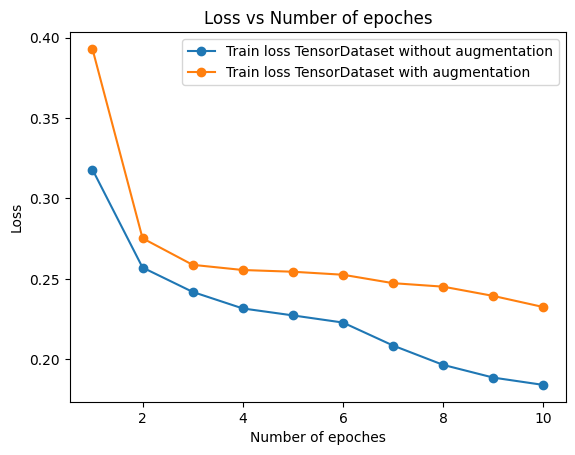

In [34]:
import matplotlib.pyplot as plt

epoches = np.arange(1,11)
plt.plot(epoches, train_loss_tensorDataset, marker='o', label='Train loss TensorDataset without augmentation')
plt.plot(epoches, train_loss_tensorDataset_aug, marker='o', label='Train loss TensorDataset with augmentation')

plt.xlabel("Number of epoches")
plt.ylabel("Loss")
plt.title("Loss vs Number of epoches")
plt.legend()

plt.show()

### GPU batch augmentations

In [35]:
def eval_cea(model, data_loader):
    model.eval() # Set model to eval mode

    losses = []
    with torch.no_grad(): # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:

            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)

            # loss
            loss = loss_module(preds, data_inputs)
            losses.append(loss.item())
    
    return losses

In [36]:
augmentations =  v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=-1)
])

def train_cae_aug(model, optimizer, data_loader, val_loader, loss_module, num_epochs=20):
    model.train()
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        epoch_loss = []
        for data_inputs, _ in data_loader:
            data_inputs = augmentations(data_inputs).to(device)
            preds = model(data_inputs)
            loss = loss_module(preds, data_inputs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss.append(loss.item())
        train_losses.append(np.mean(epoch_loss))

        val_losses.append(np.mean(eval_cea(model, val_loader)))
    return train_losses, val_losses


In [37]:
cea_gpu_aug = AutoEncoder()
cea_gpu_aug.to(device)
optimizer_cea_gpu_aug = torch.optim.Adam(cea_gpu_aug.parameters(), lr=0.001)

train_loss_cea_gpu_aug, val_loss_cea_gpu_aug = train_cae_aug(cea_gpu_aug, optimizer_cea_gpu_aug, td_train_data_loader, td_valid_data_loader, loss_module, 100)

#### Result comparaison

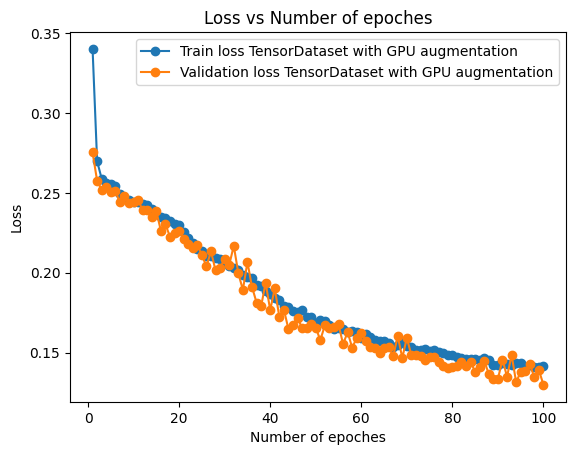

In [38]:
epoches = np.arange(1,101)
plt.plot(epoches, train_loss_cea_gpu_aug, marker='o', label='Train loss TensorDataset with GPU augmentation')
plt.plot(epoches, val_loss_cea_gpu_aug, marker='o', label='Validation loss TensorDataset with GPU augmentation')

plt.xlabel("Number of epoches")
plt.ylabel("Loss")
plt.title("Loss vs Number of epoches")
plt.legend()

plt.show()

#### Reconstructions

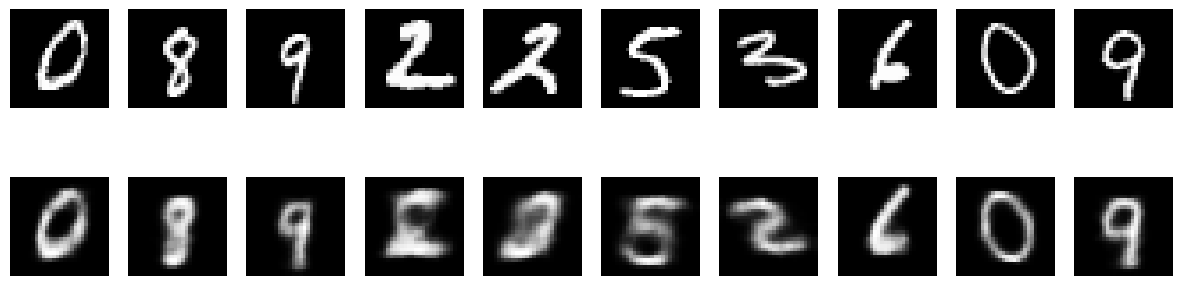

In [39]:
n = 10

images, _ = next(iter(td_valid_data_loader))
images = images[:n].to(device)

with torch.no_grad():
    recons = cea_gpu_aug(images)

images = images.cpu()
recons = recons.cpu()

plt.figure(figsize=(15, 4))

for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

    # reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recons[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

## 3.2.3 Pre-Trained Encoder for Classification

In [113]:

import torch
import torch.nn as nn

class EncoderCEA(nn.Module):

    def __init__(self):
        # Initialize the modules we need to build the network
        super().__init__()
        

        # encoder func
        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1) # in_channel (grey or RGB), nb of filter, filter size, stride
        self.maxpool = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1) # , nb of filter, filter size, stride
        self.adaptive_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear1 = nn.Linear(64, 64)



    def forward(self, x):


        # convolution 1
        x = self.conv1(x)
        x = self.relu(x)    # 14x14x32
        x = self.maxpool(x) # 7x7x32

        # convulotion 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # fully connected layers
        x = self.adaptive_avg_pool(x)
        x = torch.flatten(x, start_dim=1, end_dim=-1)        
        x = self.linear1(x)



        return x

In [114]:
trained_dict = cea_gpu_aug.state_dict()
model_encoder = EncoderCEA()

loss_module = nn.CrossEntropyLoss() # back to classification pb

# filter only encoder weights
model_encoder.load_state_dict(trained_dict, strict=False)
#freeze encoder
for param in model_encoder.parameters():
    param.requires_grad = False

In [115]:
def eval_classifier(model, data_loader):
    model.eval() # Set model to eval mode

    losses = []
    with torch.no_grad(): # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:

            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)

            # loss
            loss = loss_module(preds, data_labels)
            losses.append(loss.item())
    
    return losses

In [116]:
def train_classifier(model, optimizer, data_loader, val_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train()
    train_losses = []
    val_losses = []
    # Training loop
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = []
        for data_inputs, data_labels in data_loader:

            
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            
            preds = model(data_inputs)

            # Calculate the loss
            loss = loss_module(preds, data_labels)
            epoch_loss.append(loss.item())

            ## Step 4: Perform backpropagation
            # Before calculating the gradients, we need to ensure that they are all zero.
            # The gradients would not be overwritten, but actually added to the existing ones.
            optimizer.zero_grad()
            # Perform backpropagation
            loss.backward()

            ## Step 5: Update the parameters
            optimizer.step()
        train_losses.append(np.mean(epoch_loss))
        val_losses.append(np.mean(eval_classifier(model, val_loader)))
    return train_losses, val_losses

Classifier :

In [117]:
classifier = nn.Sequential(
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


class Classifier(nn.Module):
    def __init__(self, encoder, classifier):
        super().__init__()
        self.encoder = encoder
        self.classifier = classifier

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x
    
cea_classifier = Classifier(model_encoder, classifier)
cea_classifier.to(device)
optimizer_cea_classifier = torch.optim.Adam(cea_classifier.classifier.parameters(), lr=0.001) # only on the head
train_loss_cea_gpu_aug, val_loss_cea_gpu_aug = train_classifier(cea_classifier, optimizer_cea_classifier, td_train_data_loader, td_valid_data_loader, loss_module, 50)

  0%|          | 0/50 [00:00<?, ?it/s]

#### Accuracy

In [118]:
def eval_model_accuracy(model, data_loader):
    model.eval() # Set model to eval mode
    true_preds, num_preds = 0., 0.

    with torch.no_grad(): # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:

            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)
            preds = torch.sigmoid(preds) # Sigmoid to map predictions between 0 and 1
            _, pred_labels = torch.max(preds, dim=1) # Prediction in [1,10]

            # Keep records of predictions for the accuracy metric (true_preds=TP+TN, num_preds=TP+TN+FP+FN)
            true_preds += (pred_labels == data_labels).sum()
            num_preds += data_labels.shape[0]

    acc = true_preds / num_preds
    return acc

acc_frozen = eval_model_accuracy(cea_classifier, td_test_data_loader)
print(f"Accuracy of the model: {acc_frozen} %")

Accuracy of the model: 0.9262999892234802 %


#### Fine-tuning

In [119]:
# unfreeze 
for param in cea_classifier.encoder.parameters():
    param.requires_grad = True

# optimizer re definition
optimizer_finetune = torch.optim.Adam(cea_classifier.parameters(),lr=1e-4)   # lower learning rate

train_loss_cea_classifier, val_loss_cea_classifier = train_classifier(cea_classifier, optimizer_finetune, td_train_data_loader, td_valid_data_loader, loss_module, 50)

  0%|          | 0/50 [00:00<?, ?it/s]

#### Accuracy

In [120]:
acc_finetuned = eval_model_accuracy(cea_classifier, td_test_data_loader)
print(f"Accuracy of the model: {acc_finetuned} %")

Accuracy of the model: 0.964199960231781 %


#### Comparaison with training from scratch

We create a new instance not trained and train directly without the freeze/defreeze mechanism.

In [121]:
scratch_encoder = EncoderCEA()

# reuse same classifier
classifier = nn.Sequential(
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_scratch = Classifier(scratch_encoder, classifier)
model_scratch.to(device)

# optimizer
optimizer_scratch = torch.optim.Adam(model_scratch.parameters(),lr=1e-4)


In [122]:
train_loss_scratch, val_loss_scratch = train_classifier(model_scratch, optimizer_scratch, td_train_data_loader, td_valid_data_loader, loss_module, 50)

  0%|          | 0/50 [00:00<?, ?it/s]

#### Accuracy

In [123]:
acc_scratch = eval_model_accuracy(model_scratch, td_test_data_loader)
print(f"Accuracy of the model: {acc_scratch} %")

Accuracy of the model: 0.771399974822998 %


We have an accuracy of **93.07%** with the freeze mechanism and **78.01%** without. We can conclude that the frozen pretrained encoder results in better results.

#### Plot

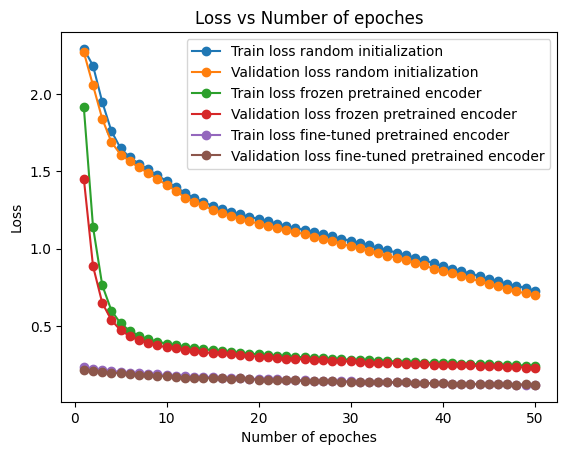

In [124]:
epochs_scratch = np.arange(1, len(train_loss_scratch) + 1)
epochs_frozen = np.arange(1, len(train_loss_cea_gpu_aug) + 1)
epochs_finetune = np.arange(1, len(train_loss_cea_classifier) + 1)

# random initialization
plt.plot(epochs_scratch, train_loss_scratch, marker='o', label='Train loss random initialization')
plt.plot(epochs_scratch, val_loss_scratch, marker='o', label='Validation loss random initialization')

# frozen pretrained encoder
plt.plot(epochs_frozen, train_loss_cea_gpu_aug, marker='o', label='Train loss frozen pretrained encoder')
plt.plot(epochs_frozen, val_loss_cea_gpu_aug, marker='o', label='Validation loss frozen pretrained encoder')

# fine-tuned pretrained encoder
plt.plot(epochs_finetune, train_loss_cea_classifier, marker='o', label='Train loss fine-tuned pretrained encoder')
plt.plot(epochs_finetune, val_loss_cea_classifier, marker='o', label='Validation loss fine-tuned pretrained encoder')


plt.xlabel("Number of epoches")
plt.ylabel("Loss")
plt.title("Loss vs Number of epoches")
plt.legend()

plt.show()

#### Results Table

In [127]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Random initialization",
        "Frozen pretrained encoder",
        "Fine-tuned pretrained encoder"
    ],
    "Test Accuracy": [
        acc_scratch,
        acc_frozen,
        acc_finetuned
    ],
    "Final Train Loss": [
        train_loss_scratch[-1],
        train_loss_cea_gpu_aug[-1],
        train_loss_cea_classifier[-1]
    ],
    "Final Val Loss": [
        val_loss_scratch[-1],
        val_loss_cea_gpu_aug[-1],
        val_loss_cea_classifier[-1]
    ]
})

print(results.to_string(index=False))

                        Model                   Test Accuracy  Final Train Loss  Final Val Loss
        Random initialization tensor(0.7714, device='cuda:0')          0.727351        0.697856
    Frozen pretrained encoder tensor(0.9263, device='cuda:0')          0.241529        0.227218
Fine-tuned pretrained encoder tensor(0.9642, device='cuda:0')          0.117778        0.119381


scratch: tend to overfitt more
